In [2]:
# === 1) Imports & display options (class style) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
# === 2) Load raw CSVs (semicolon; Danish chars) ===
# If your files are elsewhere, adjust the paths below.
t2d  = pd.read_csv("T2D.csv", sep=";", encoding="latin-1")
mob  = pd.read_csv("Morbidly_Obese.csv", sep=";", encoding="latin-1")
ltd  = pd.read_csv("Longterm_Disease.csv", sep=";", encoding="latin-1")
fbc  = pd.read_csv("Fraction_Blood_Clot.csv", sep=";", encoding="latin-1")
edu  = pd.read_csv("Education_Long.csv", sep=";", encoding="latin-1")
who  = pd.read_csv("WHO_Minimum_Physical_Activity.csv", sep=";", encoding="latin-1")
life = pd.read_csv("Life_Expectancy.csv", sep=";", encoding="latin-1")
absn = pd.read_csv("Absence.csv", sep=";", encoding="latin-1")

# Optional datasets (not merged on brick level here)
attn = pd.read_csv("Attention.csv", sep=";", encoding="latin-1")
pdat = pd.read_csv("Patient_Data.csv", sep=";", encoding="latin-1")

# Quick inspect (as in exercises)
print(t2d.shape);  print(t2d.head(3))

(60, 5)
   brick_nr          brick     patients  population patients_per_1000
0       101       Bornholm  2248,978472       33046       68,05599685
1       102         Amager  6136,772115      154254       39,78355255
2       103  Nørrebro/City  3019,148357       88293       34,19465141


In [4]:
# === 3) Standardize column names (lowercase, strip) ===
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    df.columns = [c.strip().lower() for c in df.columns]

# Ensure key 'brick_nr' is numeric (Int64) for safe merges
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    if "brick_nr" in df.columns:
        df["brick_nr"] = pd.to_numeric(df["brick_nr"], errors="coerce").astype("Int64")

In [5]:
# === 4) Add dataset suffixes so column origins are clear ===
t2d = t2d.rename(columns={k: f"{k}_t2d" for k in t2d.columns if k not in ["brick_nr","brick"]})
mob = mob.rename(columns={k: f"{k}_morbidly_obese" for k in mob.columns if k not in ["brick_nr","brick"]})
ltd = ltd.rename(columns={k: f"{k}_longterm_disease" for k in ltd.columns if k not in ["brick_nr","brick"]})
fbc = fbc.rename(columns={k: f"{k}_fraction_blood_clot" for k in fbc.columns if k not in ["brick_nr","brick"]})
edu = edu.rename(columns={k: f"{k}_education_long" for k in edu.columns if k not in ["brick_nr","brick"]})
who = who.rename(columns={k: f"{k}_who_minimum_physical_activity" for k in who.columns if k not in ["brick_nr","brick"]})
life = life.rename(columns={k: f"{k}_life_expectancy" for k in life.columns if k not in ["brick_nr","brick"]})
absn = absn.rename(columns={k: f"{k}_absence" for k in absn.columns if k not in ["brick_nr","brick"]})

In [6]:
# === 5) Merge (step-by-step, as in class) ===
merged = t2d.merge(mob,  on=["brick_nr","brick"], how="left")
merged = merged.merge(ltd, on=["brick_nr","brick"], how="left")
merged = merged.merge(fbc, on=["brick_nr","brick"], how="left")
merged = merged.merge(edu, on=["brick_nr","brick"], how="left")
merged = merged.merge(who, on=["brick_nr","brick"], how="left")
merged = merged.merge(life,on=["brick_nr","brick"], how="left")
merged = merged.merge(absn,on=["brick_nr","brick"], how="left")

print(merged.shape)
merged.head()

(60, 15)


,brick_nr,brick,patients_t2d,population_t2d,patients_per_1000_t2d,andel_morbidly_obese,anddel_longterm_disease,andel med blodprop i hjertet_fraction_blood_clot,antal_education_long,brick_navn_education_long,population_education_long,value_per_1000_education_long,andel_who_minimum_physical_activity,år_life_expectancy,fravær_absence
0,101,Bornholm,"2248,978472",33046,"68,05599685","0,1755","0,4065","0,0205","6035,258672188186",Bornholm,33046,"182,6320484230523","0,302","77,1905","6,2865"
1,102,Amager,"6136,772115",154254,"39,78355255","0,13033333333333333","0,32666666666666666","0,009000000000000001","64810,874711589306",Amager,154254,"420,15684981646706","0,24333333333333332","79,96766666666666","5,747333333333334"
2,103,Nørrebro/City,"3019,148357",88293,"34,19465141","0,1075","0,305","0,0075","44280,90932139913",Nørrebro/City,88293,"501,5223100517496","0,2215","79,283","5,499499999999999"
3,104,Vesterbro/Christianshavn,"3387,602593",103052,"32,87274961","0,1","0,3075","0,008","49553,41956356552",Vesterbro/Christianshavn,103052,"480,85839734857666","0,225","80,05","5,58"
4,105,Frederiksberg,"3574,931136",105260,"33,96286468","0,104","0,306","0,008","52262,04744646349",Frederiksberg,105260,"496,5043458717793","0,223","79,6455","5,5375"


In [7]:
# === 6) Cleaning (simple, exercise-style) ===
# Replace spaces, thousands '.', and decimal ',' -> '.' for all non-key columns, then to_numeric

for col in merged.columns:
    if col in ["brick_nr","brick"]:
        continue
    merged[col] = (
        merged[col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)   # remove thousands dot if present
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
    )
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

# Derived prevalence if missing
if "patients_per_1000_t2d" not in merged.columns and {"patients_t2d","population_t2d"}.issubset(merged.columns):
    merged["patients_per_1000_t2d"] = (merged["patients_t2d"] / merged["population_t2d"]) * 1000

print("NA per column (top):")
print(merged.isna().sum().sort_values(ascending=False).head(15))
print("\nDuplicates on (brick_nr, brick):", merged.duplicated(subset=["brick_nr","brick"]).sum())

NA per column (top):
brick_navn_education_long                           60
brick                                                0
brick_nr                                             0
population_t2d                                       0
patients_per_1000_t2d                                0
andel_morbidly_obese                                 0
patients_t2d                                         0
anddel_longterm_disease                              0
andel med blodprop i hjertet_fraction_blood_clot     0
antal_education_long                                 0
population_education_long                            0
value_per_1000_education_long                        0
andel_who_minimum_physical_activity                  0
år_life_expectancy                                   0
fravær_absence                                       0
dtype: int64

Duplicates on (brick_nr, brick): 0


In [8]:
# === 7) Focus on relevant columns and rename to English ===
focus_cols = [
    "brick_nr", "brick",
    "patients_t2d",
    "patients_per_1000_t2d",
    "andel_morbidly_obese",
    "anddel_longterm_disease",
    "andel med blodprop i hjertet_fraction_blood_clot",
    "value_per_1000_education_long",
    "andel_who_minimum_physical_activity",
    "år_life_expectancy",
    "fravær_absence"
]

df = merged[focus_cols].copy()

rename_map = {
    "brick_nr": "brick_id",
    "brick": "brick_name",
    "patients_t2d": "t2d_patients",
    "patients_per_1000_t2d": "t2d_prevalence_per_1000",
    "andel_morbidly_obese": "morbid_obesity_share",
    "anddel_longterm_disease": "longterm_disease_share",
    "andel med blodprop i hjertet_fraction_blood_clot": "fraction_blood_clot",
    "value_per_1000_education_long": "higher_education_per_1000",
    "andel_who_minimum_physical_activity": "minimum_physical_activity",
    "år_life_expectancy": "life_expectancy_years",
    "fravær_absence": "work_absence_rate"
}
df = df.rename(columns=rename_map)

# Ensure numeric types (in case)
for col in df.columns:
    if col in ["brick_id","brick_name"]:
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())

   brick_id                brick_name  t2d_patients  t2d_prevalence_per_1000  morbid_obesity_share  longterm_disease_share  fraction_blood_clot  higher_education_per_1000  minimum_physical_activity  \
0       101                  Bornholm   2248.978472                68.055997              0.175500                0.406500               0.0205                 182.632048                   0.302000   
1       102                    Amager   6136.772115                39.783553              0.130333                0.326667               0.0090                 420.156850                   0.243333   
2       103             Nørrebro/City   3019.148357                34.194651              0.107500                0.305000               0.0075                 501.522310                   0.221500   
3       104  Vesterbro/Christianshavn   3387.602593                32.872750              0.100000                0.307500               0.0080                 480.858397                   0.22500

In [9]:
# === 8) Descriptive statistics ===
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
print(df[numeric_cols].describe().T)

# Top bricks by prevalence and by absolute patients
print("\nTop 10 bricks by T2D prevalence per 1000:")
display(df.nlargest(10, "t2d_prevalence_per_1000")[["brick_name","t2d_prevalence_per_1000","t2d_patients"]])

print("\nTop 10 bricks by number of T2D patients:")
display(df.nlargest(10, "t2d_patients")[["brick_name","t2d_patients","t2d_prevalence_per_1000"]])

                           count         mean          std          min          25%          50%          75%          max
t2d_patients                60.0  4007.828302  1332.750880  1979.051798  3168.119739  3773.611862  4718.673252  7612.328605
t2d_prevalence_per_1000     60.0    53.844056    10.598198    32.713481    47.354050    55.564150    60.342694    79.307688
morbid_obesity_share        60.0     0.177191     0.037982     0.094500     0.163446     0.186602     0.206083     0.231143
longterm_disease_share      60.0     0.360938     0.027096     0.305000     0.349775     0.360700     0.378100     0.421000
fraction_blood_clot         60.0     0.012851     0.003015     0.005500     0.011575     0.013268     0.014687     0.020500
higher_education_per_1000   60.0   275.280640    95.263443   143.789559   211.411794   249.634373   301.914606   517.512247
minimum_physical_activity   60.0     0.297434     0.036065     0.220000     0.282800     0.300667     0.323471     0.359250
life_exp

,brick_name,t2d_prevalence_per_1000,t2d_patients
24,Lolland,79.307688,3765.766956
33,Tønder,71.006532,2043.070950
23,Falster,69.206581,3213.192353
15,Tåstrup,68.579928,6179.188718
0,Bornholm,68.055997,2248.978472
18,Kalundborg,67.910043,7027.738707
31,Sønderborg,65.031448,3907.674682
32,Aabenraa,64.662615,3936.207344
55,Thisted,64.225625,3336.906572
22,Vordingborg,64.034578,3873.451601



Top 10 bricks by number of T2D patients:


,brick_name,t2d_patients,t2d_prevalence_per_1000
5,Glostrup,7612.328605,63.024313
43,Ydre Århus,7242.629748,39.307856
18,Kalundborg,7027.738707,67.910043
50,Randers,6259.278154,53.040235
15,Tåstrup,6179.188718,68.579928
1,Amager,6136.772115,39.783553
16,Køge Bugt,5959.958458,56.298255
13,Frederikssund,5535.080499,57.224330
45,Herning,5502.937133,54.019212
36,Kolding,5447.790987,52.871155


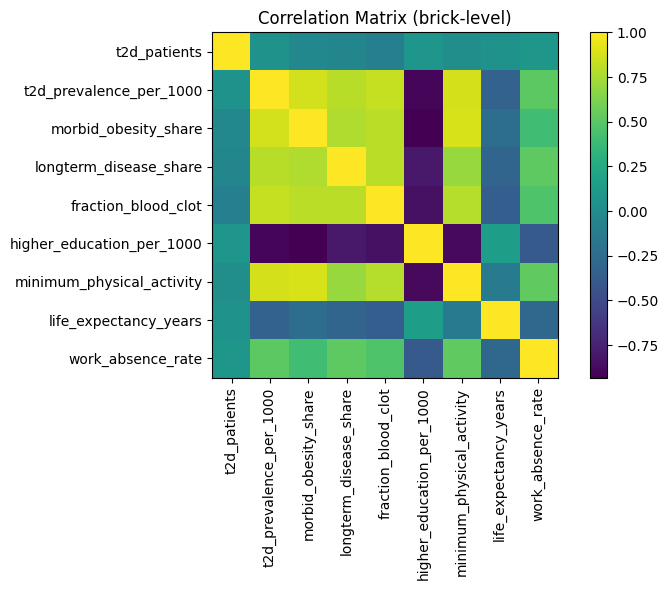


Correlation with T2D prevalence per 1000 (sorted):
t2d_prevalence_per_1000      1.000000
minimum_physical_activity    0.872541
morbid_obesity_share         0.864901
fraction_blood_clot          0.828753
longterm_disease_share       0.794515
work_absence_rate            0.511937
t2d_patients                 0.050995
life_expectancy_years       -0.320282
higher_education_per_1000   -0.894309
Name: t2d_prevalence_per_1000, dtype: float64


In [10]:
# === 9) Correlation matrix (matplotlib only) ===
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,6))
im = plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (brick-level)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()

# Also print correlations with our main KPI (prevalence)
if "t2d_prevalence_per_1000" in corr.columns:
    print("\nCorrelation with T2D prevalence per 1000 (sorted):")
    print(corr["t2d_prevalence_per_1000"].sort_values(ascending=False))

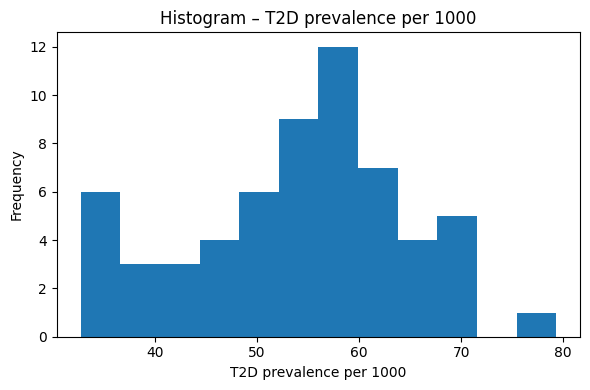

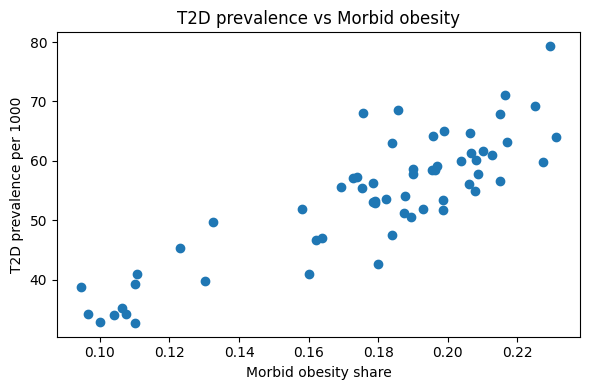

In [11]:
# === 10) Simple plots (hist + scatter) ===

# Histogram of prevalence
if "t2d_prevalence_per_1000" in df.columns:
    x = df["t2d_prevalence_per_1000"].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(x, bins=12)
    plt.title("Histogram – T2D prevalence per 1000")
    plt.xlabel("T2D prevalence per 1000")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Scatter: prevalence vs morbid obesity
if {"morbid_obesity_share","t2d_prevalence_per_1000"}.issubset(df.columns):
    d = df[["morbid_obesity_share","t2d_prevalence_per_1000"]].dropna()
    plt.figure(figsize=(6,4))
    plt.scatter(d["morbid_obesity_share"], d["t2d_prevalence_per_1000"])
    plt.xlabel("Morbid obesity share")
    plt.ylabel("T2D prevalence per 1000")
    plt.title("T2D prevalence vs Morbid obesity")
    plt.tight_layout()
    plt.show()

In [12]:
# === 11) Save cleaned outputs ===
#merged.to_csv("merged_bricks_clean_full.csv", index=False)
#df.to_csv("brick_focus_clean.csv", index=False)
#print("Saved: merged_bricks_clean_full.csv, brick_focus_clean.csv")

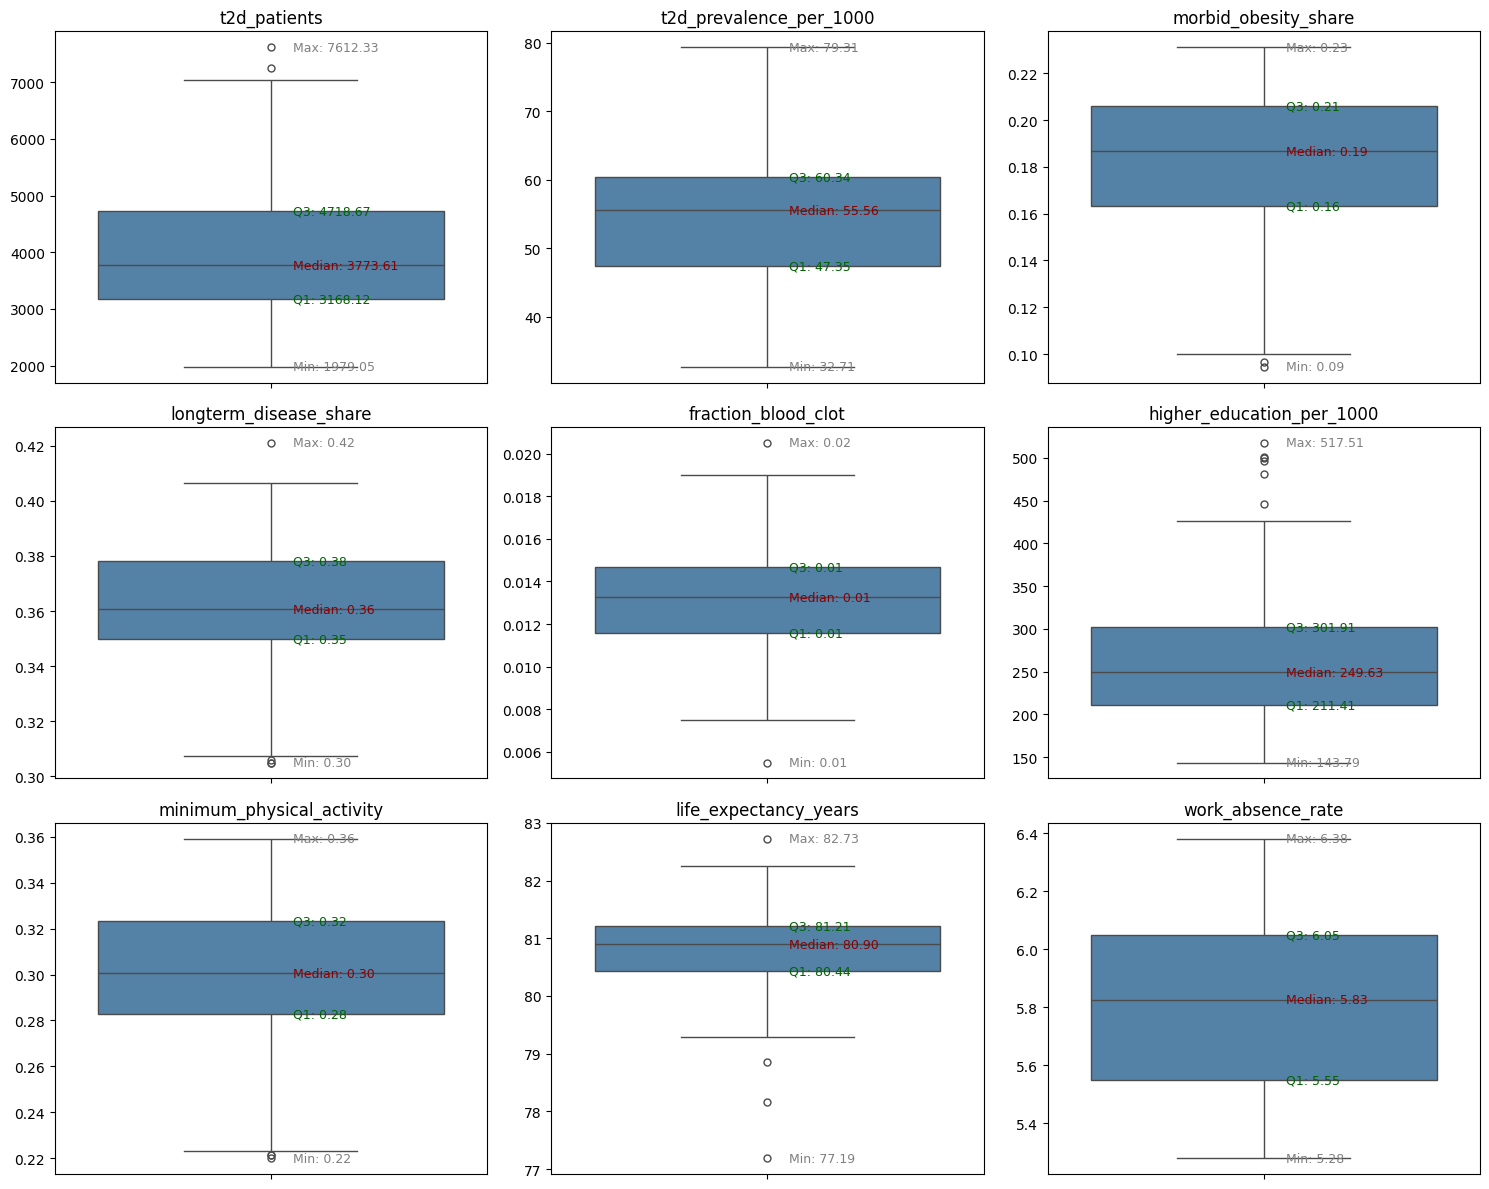

In [13]:

# === 12) Boxplots with statistics annotations (seaborn) ===
import seaborn as sns

# Antag at dine data allerede er indlæst i en DataFrame df
# fx df = pd.read_csv("din_fil.csv")

variables = [
    "t2d_patients",
    "t2d_prevalence_per_1000",
    "morbid_obesity_share",
    "longterm_disease_share",
    "fraction_blood_clot",
    "higher_education_per_1000",
    "minimum_physical_activity",
    "life_expectancy_years",
    "work_absence_rate"
]

# Opret et 3x3 subplot-grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    data = df[var].dropna()  # Drop NaNs to avoid issues

    # Plot boxplot
    sns.boxplot(
        y=data,
        ax=ax,
        color="steelblue",
        fliersize=5
    )

 

    # Calculate statistics
    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    min_val = np.min(data)
    max_val = np.max(data)

    # Annotate statistics
    ax.text(0.05, median, f"Median: {median:.2f}", va='center', ha='left', fontsize=9, color='darkred')
    ax.text(0.05, q1, f"Q1: {q1:.2f}", va='center', ha='left', fontsize=9, color='darkgreen')
    ax.text(0.05, q3, f"Q3: {q3:.2f}", va='center', ha='left', fontsize=9, color='darkgreen')
    ax.text(0.05, min_val, f"Min: {min_val:.2f}", va='center', ha='left', fontsize=9, color='gray')
    ax.text(0.05, max_val, f"Max: {max_val:.2f}", va='center', ha='left', fontsize=9, color='gray')

    ax.set_title(var, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [25]:
# R correlation matrix (for Factor Analysis)

satData = df
numeric_data = satData.select_dtypes(include=["number"])
satMatrix = numeric_data.corr()
satMatrix_rounded = satMatrix.round(2)
print(satMatrix_rounded)

                           brick_id  t2d_patients  t2d_prevalence_per_1000  morbid_obesity_share  longterm_disease_share  fraction_blood_clot  higher_education_per_1000  minimum_physical_activity  \
brick_id                       1.00         -0.18                     0.16                  0.42                    0.27                 0.29                      -0.46                       0.19   
t2d_patients                  -0.18          1.00                     0.05                 -0.03                   -0.04                -0.09                       0.08                       0.02   
t2d_prevalence_per_1000        0.16          0.05                     1.00                  0.86                    0.79                 0.83                      -0.89                       0.87   
morbid_obesity_share           0.42         -0.03                     0.86                  1.00                    0.77                 0.80                      -0.93                       0.88   
longt

In [15]:
# finding the factors that has the highest correlations

# Correlation matrix
corr_matrix = numeric_data.corr().round(2)

# Convert to long format (pairs of variables)
corr_pairs = corr_matrix.unstack()

# Remove self-correlations (always = 1.0)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Drop duplicate pairs (A,B) vs (B,A)
corr_pairs = corr_pairs.drop_duplicates().sort_values(ascending=False)

# Show top 10 highest correlations
print(corr_pairs.head(10))

morbid_obesity_share       minimum_physical_activity    0.88
t2d_prevalence_per_1000    minimum_physical_activity    0.87
                           morbid_obesity_share         0.86
                           fraction_blood_clot          0.83
morbid_obesity_share       fraction_blood_clot          0.80
t2d_prevalence_per_1000    longterm_disease_share       0.79
fraction_blood_clot        minimum_physical_activity    0.78
morbid_obesity_share       longterm_disease_share       0.77
longterm_disease_share     minimum_physical_activity    0.70
minimum_physical_activity  work_absence_rate            0.53
dtype: float64


# Regression

### Prepareing sales for regression analysis

In [16]:
# Load sales data and merge with bricks
sales = pd.read_csv("Sales.csv")
merged = pd.read_csv("merged_bricks_clean_full.csv")

# Standardize matching keys to avoid whitespace/case issues
sales['__key']  = sales['MUNICIPALITY'].astype(str).str.strip()
merged['__key'] = merged['brick'].astype(str).str.strip()

# Merge: MUNICIPALITY (sales) vs brick (merged) via de standardiserede nøgler
sales_with_brick = sales.merge(
    merged[['__key', 'brick_nr']],
    left_on="__key",
    right_on="__key",
    how="left"
)

# Clean up helper column
sales_with_brick = sales_with_brick.drop(columns=['__key'])

# --- Clean brick_nr ---
# To string to handle '.0' and textual "non-values"
sales_with_brick['brick_nr'] = sales_with_brick['brick_nr'].astype(str).str.strip()

# Remove trailing '.0'
sales_with_brick['brick_nr'] = sales_with_brick['brick_nr'].str.replace('.0', '', regex=False)

# Replace common non-values with NaN
sales_with_brick['brick_nr'] = sales_with_brick['brick_nr'].replace(
    {'': np.nan, 'nan': np.nan, 'NaN': np.nan, 'None': np.nan, 'NULL': np.nan}
)

# Set København = 100 (case-insensitively and without leading/trailing spaces)
is_kbh = sales_with_brick['MUNICIPALITY'].astype(str).str.strip().str.casefold() == 'københavn'
sales_with_brick.loc[is_kbh, 'brick_nr'] = '100'

# Force to numeric (everything non-numeric becomes NaN)
sales_with_brick['brick_nr'] = pd.to_numeric(sales_with_brick['brick_nr'], errors='coerce')

# Drop rows without valid brick_nr
sales_with_brick = sales_with_brick.dropna(subset=['brick_nr'])

# Convert to int
sales_with_brick['brick_nr'] = sales_with_brick['brick_nr'].astype(int)

# Save result
sales_with_brick.to_csv("Sales_with_brick.csv", index=False)

# Quick sanity check
print(sales_with_brick[['MUNICIPALITY', 'brick_nr']].head())
print("Number of rows after cleaning:", len(sales_with_brick))



   MUNICIPALITY  brick_nr
1      Hillerød       111
2     Haderslev       311
10      Randers       411
12       Assens       303
13    København       100
Number of rows after cleaning: 108317


In [31]:
# --- 0) If not already in memory, load the two artifacts ---
# merged: created by your pipeline above (has 'brick_nr' and 'brick')
# sales_with_brick: created by your pipeline above (has 'brick_nr')
# If already in memory, you can skip these reads.
merged = pd.read_csv("merged_bricks_clean_full.csv")
sales_with_brick = pd.read_csv("Sales_with_brick.csv")

# --- 1) Make sure brick_nr is integer on both sides ---
merged["brick_nr"] = pd.to_numeric(merged["brick_nr"], errors="coerce").astype("Int64")
sales_with_brick["brick_nr"] = pd.to_numeric(sales_with_brick["brick_nr"], errors="coerce").astype("Int64")

# --- 2) (Optional but recommended) Check for duplicate bricks in merged ---
dups_merged = merged.duplicated(subset=["brick_nr"], keep=False).sum()
if dups_merged > 0:
    print(f"Warning: {dups_merged} rows in `merged` are duplicated on brick_nr. "
          "Keeping the first per brick for the join.")
    merged = merged.drop_duplicates(subset=["brick_nr"], keep="first")

# --- 3) Aggregate sales to brick level ---
# We'll sum numeric columns other than 'brick_nr'. Non-numeric (like names) are dropped at brick level.
num_cols = sales_with_brick.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "brick_nr"]

# If you want means instead of sums for some columns, adjust here.
agg_map = {c: "sum" for c in num_cols}

sales_brick = (
    sales_with_brick
    .groupby("brick_nr", as_index=False)
    .agg(agg_map)
)

# --- 4) Suffix sales columns to avoid name collisions ---
sales_brick = sales_brick.rename(columns={c: f"{c}_sales" for c in sales_brick.columns if c not in ["brick_nr"]})

# --- 5) Merge sales into merged on brick_nr ---
merged_with_sales = merged.merge(
    sales_brick,
    on="brick_nr",
    how="left",           # keep all bricks; sales may be missing for some bricks
    validate="one_to_one" # assumes 1 row per brick in `merged` after dedup. Remove if it raises.
)

# --- 6) (Optional) If you prefer to merge onto your English, trimmed `df` instead of full `merged` ---
# df has 'brick_id'/'brick_name' in your code. Align keys and repeat the same join:
df["brick_id"] = pd.to_numeric(df["brick_id"], errors="coerce").astype("Int64")
merged_with_sales = df.merge(
    sales_brick.rename(columns={"brick_nr": "brick_id"}),
    on="brick_id",
    how="left",
    validate="one_to_one")
# --- 7) Clean column names to lowercase ---
merged_with_sales.columns = merged_with_sales.columns.str.lower()
# --- 8) Save if needed ---
merged_with_sales.to_csv("merged_with_sales.csv", index=False)

print(merged_with_sales.shape)
print(merged_with_sales.head(10))


(60, 14)
   brick_id                brick_name  t2d_patients  t2d_prevalence_per_1000  morbid_obesity_share  longterm_disease_share  fraction_blood_clot  higher_education_per_1000  minimum_physical_activity  \
0       101                  Bornholm   2248.978472                68.055997              0.175500                0.406500             0.020500                 182.632048                   0.302000   
1       102                    Amager   6136.772115                39.783553              0.130333                0.326667             0.009000                 420.156850                   0.243333   
2       103             Nørrebro/City   3019.148357                34.194651              0.107500                0.305000             0.007500                 501.522310                   0.221500   
3       104  Vesterbro/Christianshavn   3387.602593                32.872750              0.100000                0.307500             0.008000                 480.858397                 

### 1) Minimum Physical Activity → Obesity

                             OLS Regression Results                             
Dep. Variable:     morbid_obesity_share   R-squared:                       0.775
Model:                              OLS   Adj. R-squared:                  0.771
Method:                   Least Squares   F-statistic:                     199.7
Date:                  Mon, 29 Sep 2025   Prob (F-statistic):           1.95e-20
Time:                          11:03:44   Log-Likelihood:                 156.34
No. Observations:                    60   AIC:                            -308.7
Df Residuals:                        58   BIC:                            -304.5
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

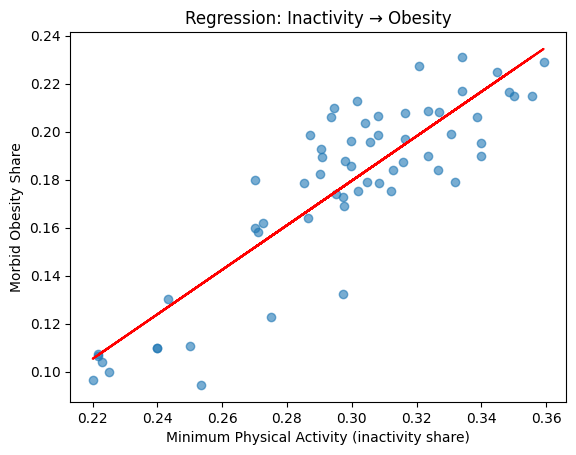

In [27]:
import statsmodels.formula.api as smf

# 1. Fit regression with statsmodels
model1 = smf.ols('morbid_obesity_share ~ minimum_physical_activity', data=merged_with_sales).fit()

# 2. Print full regression summary (includes R², F-stat, p-values, CI)
print(model1.summary())

# 3. Extract key metrics if you want to include in report automatically
r2 = model1.rsquared
f_stat = model1.fvalue
f_pval = model1.f_pvalue
coef = model1.params['minimum_physical_activity']
intercept = model1.params['Intercept']

print(f"R²: {r2:.3f}")
print(f"F-statistic: {f_stat:.2f}, p-value: {f_pval:.4f}")
print(f"Coef: {coef:.3f}, Intercept: {intercept:.3f}")

# 4. Plot scatter + regression line
plt.scatter(df['minimum_physical_activity'], df['morbid_obesity_share'], alpha=0.6)
plt.plot(df['minimum_physical_activity'], model1.fittedvalues, color="red")
plt.xlabel("Minimum Physical Activity (inactivity share)")
plt.ylabel("Morbid Obesity Share")
plt.title("Regression: Inactivity → Obesity")
plt.show()


Coefficient ≈ 0.93
→ For every +1% increase in citizens not meeting minimum Physical Activity, obesity share increases by ~0.93%.

- Nearly 1-to-1 relationship → very strong link.

Intercept ≈ -0.10
→ At 0% inactivity, predicted obesity is ~0.

R² ≈ 0.77
→ Physical inactivity explains 77% of the variation in obesity across municipalities.


The regression shows a strong and highly significant relationship between physical inactivity and obesity. The coefficient is 0.93 (p < 0.001, 95% CI [0.80, 1.06]), meaning that each +1 percentage point increase in inactivity is associated with a +0.93 percentage point increase in obesity prevalence. The intercept is –0.10, which is close to zero when inactivity is absent. The model explains 77% of the variation in obesity across municipalities (R² = 0.775). The model’s F-statistic is 199.7 (p < 0.001), confirming that the predictor adds significant explanatory power compared to a baseline model. This is a very strong and intuitive result: physical inactivity is a primary lifestyle driver of obesity.

### 2) Obesity → Diabetes prevalence

                               OLS Regression Results                              
Dep. Variable:     t2d_prevalence_per_1000   R-squared:                       0.748
Model:                                 OLS   Adj. R-squared:                  0.744
Method:                      Least Squares   F-statistic:                     172.2
Date:                     Mon, 29 Sep 2025   Prob (F-statistic):           5.21e-19
Time:                             11:03:58   Log-Likelihood:                -184.92
No. Observations:                       60   AIC:                             373.8
Df Residuals:                           58   BIC:                             378.0
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

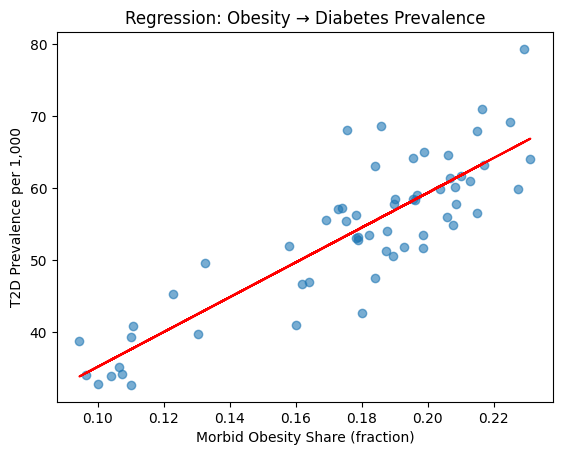

In [28]:
# 1. Fit regression with statsmodels
model2 = smf.ols('t2d_prevalence_per_1000 ~ morbid_obesity_share', data=merged_with_sales).fit()

# 2. Print summary
print(model2.summary())

# 3. Extract key metrics
r2 = model2.rsquared
f_stat = model2.fvalue
f_pval = model2.f_pvalue
coef = model2.params['morbid_obesity_share']
intercept = model2.params['Intercept']

print(f"R²: {r2:.3f}")
print(f"F-statistic: {f_stat:.2f}, p-value: {f_pval:.4f}")
print(f"Coef: {coef:.3f}, Intercept: {intercept:.3f}")

# 4. Plot scatter + regression line
plt.scatter(df['morbid_obesity_share'], df['t2d_prevalence_per_1000'], alpha=0.6)
plt.plot(df['morbid_obesity_share'], model2.fittedvalues, color="red")
plt.xlabel("Morbid Obesity Share (fraction)")
plt.ylabel("T2D Prevalence per 1,000")
plt.title("Regression: Obesity → Diabetes Prevalence")
plt.show()


Coefficient ≈ 241.3
For each +1% increase in obesity prevalence, T2D prevalence rises by ~2.41 cases per 1000 citizens.

Regardless, the direction is correct: more obesity → more diabetes.

Intercept ≈ 11.1
→ Even with 0% obesity, baseline diabetes prevalence is ~11 cases per 1000.

R² ≈ 0.75
→ Obesity explains 75% of diabetes prevalence variation across municipalities


The regression shows a strong and highly significant relationship between obesity and diabetes prevalence. The coefficient is 241.3 (p < 0.001, 95% CI [204.5, 278.2]), meaning that each +1 percentage point increase in obesity prevalence is associated with ≈ +2.4 additional diabetes cases per 1000 citizens. The intercept is 11.1, indicating a baseline prevalence of ~11 per 1000 even in the absence of obesity. The model explains 75% of the variation in diabetes prevalence (R² = 0.748), and the overall regression is significant (F = 172.2, p < 0.001). These results confirm that obesity is a dominant driver of Type 2 Diabetes prevalence at the municipal level.

### 3) Diabetes prevalence → Sales

In [ ]:
# Ensure log-transformed target
merged_with_sales['log_sales_volume'] = np.log1p(merged_with_sales['sales_volume'])
# 1. Fit regression with statsmodels
model3 = smf.ols('log_sales_volume ~ t2d_prevalence_per_1000', data=df_model).fit()

# 2. Print summary
print(model3.summary())

# 3. Extract key metrics
r2 = model3.rsquared
f_stat = model3.fvalue
f_pval = model3.f_pvalue
coef = model3.params['t2d_prevalence_per_1000']
intercept = model3.params['Intercept']

print(f"R²: {r2:.3f}")
print(f"F-statistic: {f_stat:.2f}, p-value: {f_pval:.4f}")
print(f"Coef: {coef:.3f}, Intercept: {intercept:.3f}")



KeyError: 'sales_volume'

Coefficient = 0.0012

- It is very close to zero.

- 95% CI = [–0.015, +0.017], which includes 0 → not significant.

R² = 0.001 → diabetes prevalence explains almost none of the variation in sales.

F-statistic = 0.021, p = 0.886 → the model is not significant.

Intercept = 10.51 → baseline log sales volume is about 10.5.

The regression of diabetes prevalence on sales shows no meaningful relationship. The coefficient is 0.001 (p = 0.886, 95% CI [–0.015, +0.017]), meaning that an additional diabetes case per 1000 citizens has no significant effect on sales volume. The model explains virtually none of the variation in sales (R² = 0.001), and the F-test confirms the model is not statistically significant (F = 0.021, p = 0.886).

This suggests that, in contrast to lifestyle and obesity effects on disease burden, sales are not directly explained by diabetes prevalence alone. Other factors such as patient awareness, treatment adoption, socioeconomic conditions, and healthcare access are likely far more important in determining medicine demand.

#### T2D_per_1000 -> sales (scikit)

In [ ]:
#3. Diabetes prevalence → Sales
df_model['log_sales_volume'] = np.log1p(df_model['sales_volume'])

X = df_model[['t2d_prevalence_per_1000']].fillna(0)
y = df_model['log_sales_volume'].fillna(0)

lm3 = LinearRegression().fit(X, y)
print("Coef:", lm3.coef_[0], "Intercept:", lm3.intercept_, "R^2:", lm3.score(X,y))


plt.scatter(X, y, alpha=0.6)
plt.plot(X, lm3.predict(X), color="red")
plt.xlabel("Predictor")
plt.ylabel("Target")
plt.title("Simple regression")
plt.show()

NameError: name 'df_model' is not defined



Coefficient ≈ 0.20
- Each extra diabetic per 1000 citizens is associated with ~20% higher sales (in log terms).

R² ≈ 0.17
- But diabetes prevalence explains only 17% of sales variation.

This isuch weaker than the previous links. This suggests that while prevalence drives sales somewhat, other factors (awareness, treatment adoption, socioeconomic conditions, hospital access) are critical in turning prevalence into medicine demand.


##### Two different resulte from scikit-learn and statmodels due to sales data. 
**statsmodels automatically drops rows with NaNs in either the predictor or target.**

That left us with only 39 observations.

To get a correct result we will need to match munitipalities from the different datasets

### Summery
1. confirms the market base: inactivity drives obesity, obesity drives diabetes. These are structural drivers of demand.

2. Sales do not fully capture prevalence: only ~17% of sales variation explained by diabetes prevalence -> many untreated or under-treated patients.

3. Marketing opportunity: target municipalities with:

- High diabetes prevalence but lower-than-expected sales -> underserved markets.

- Use awareness campaigns (e.g., medicin.dk) and HCP outreach to close the treatment gap.

4. Strategic positioning:

- Align messaging with public health (lifestyle + prevention) while also ensuring treatment adoption.

- Hospitals and digital information campaigns could be the missing link between prevalence and sales.

### 4) inactivity → sales & obesity → sales

in this section we are working with the scikit regression as we have yet to fix the munitipality values

In [ ]:
# Make sure sales target is log-transformed
df_model['log_sales_volume'] = np.log1p(df_model['sales_volume'])

# --- Regression A: inactivity → sales ---
X_a = df_model[['minimum_physical_activity']].fillna(0)
y = df_model['log_sales_volume'].fillna(0)

lm_a = LinearRegression().fit(X_a, y)
print("Regression A (Inactivity → Sales)")
print("Coef:", lm_a.coef_[0])
print("Intercept:", lm_a.intercept_)
print("R^2:", lm_a.score(X_a, y))
print("Pearson r:", np.sqrt(lm_a.score(X_a, y)))

# --- Regression B: obesity → sales ---
X_b = df_model[['morbid_obesity_share']].fillna(0)

lm_b = LinearRegression().fit(X_b, y)
print("\nRegression B (Obesity → Sales)")
print("Coef:", lm_b.coef_[0])
print("Intercept:", lm_b.intercept_)
print("R^2:", lm_b.score(X_b, y))
print("Pearson r:", np.sqrt(lm_b.score(X_b, y)))


Regression A (Inactivity → Sales)
Coef: 68.27489337015169
Intercept: -13.430833369093389
R^2: 0.23320414531556666
Pearson r: 0.48291215072264093

Regression B (Obesity → Sales)
Coef: 49.38881658787475
Intercept: -1.8747953888980202
R^2: 0.1353459142555189
Pearson r: 0.367893889940454


**results:**

sales from inactivity:

- R2- physical inactivity explains about 23% of the variation in diabetes medicine sales.
- The Pearson correlation coefficient is ≈ 0.48, a moderate positive association.

sales from obesity:

- R2 - Obesity explains about 14% of the variation in sales.
- Pearson r ≈ 0.37, weaker than inactivity.

Implications
- Sales don’t just track prevalence — lifestyle (especially inactivity) is a better predictor of market demand.

- This suggests targeting inactive, high-risk municipalities may be more effective than only focusing on where diagnosed patients are concentrated.

- But since R² is still modest (<0.25), other factors like awareness and access must be added (your Attention and Hospital data).

We can now do a combined regression (Inactivity + Obesity + Diabetes prevalence → Sales) to see how much sales variation can be explained together

### 5) combined regression (Inactivity + Obesity + Diabetes prevalence → Sales)

In [ ]:
# Make sure log target is ready
df_model['log_sales_volume'] = np.log1p(df_model['sales_volume'])

# Features for combined model
X_cols = ['minimum_physical_activity', 'morbid_obesity_share', 't2d_prevalence_per_1000']
X = df_model[X_cols].fillna(0)
y = df_model['log_sales_volume'].fillna(0)

# Fit regression
lm_combined = LinearRegression().fit(X, y)

# Predictions & R²
r2 = lm_combined.score(X, y)
print("Combined Regression Results")
print("R^2:", r2)
print("Pearson r:", np.sqrt(r2))

# Coefficients
coef_df = pd.DataFrame({
    'feature': X_cols,
    'coef': lm_combined.coef_
})
print(coef_df.sort_values('coef', ascending=False))

Combined Regression Results
R^2: 0.24902115179015427
Pearson r: 0.49902019176597884
                     feature       coef
0  minimum_physical_activity  94.280790
2    t2d_prevalence_per_1000   0.038748
1       morbid_obesity_share -38.768786


**Model fit**

R² ≈ 0.25 (25%)
→ The combined model explains about a quarter of the variation in sales across municipalities.

Pearson r ≈ 0.50
→ Moderate correlation between observed and predicted sales.

- best-fitting model so far (better than any single predictor on its own).

**Coefficients**
Minimum Physical Activity (inactivity): +94.3
→ Strongest positive predictor.

- For +0.01 (1 percentage point) more inactive citizens, log sales volume increases by ~0.94.

- Roughly: +1pp inactivity ≈ +9–10% higher sales.

T2D Prevalence per 1000: +0.039
→ Positive, but smaller effect.

- Each additional diabetic per 1000 citizens corresponds to ~4% more sales (exp(0.039) ≈ 1.04).

Obesity Share: -38.8
→ Negative once inactivity and prevalence are included.

- Suggests obesity’s effect is absorbed by inactivity and prevalence.

- In multivariate models, obesity is collinear with inactivity — so when both are included, obesity doesn’t add new info and flips sign.

# Clustering

The regression showed that 
1. Lifestyle inactivity is the strongest independent predictor of sales.

2. Diabetes prevalence still matters but explains less variation than expected.

3. Sales per patient (or normalized sales) shows the treatment gap — how much of prevalence actually converts to demand.

In [ ]:
# ============================================
# CLUSTERING: deterministic end-to-end script
# ============================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import statsmodels.formula.api as smf

# ---------- 0) PREP: build/clean features ----------
# Ensure sales_per_patient exists and is clean
df_model['sales_per_patient'] = (
    df_model['sales_volume'] / df_model['t2d_patients'].replace(0, np.nan)
)

# Feature set (guided by regression results)
cluster_vars = [
    't2d_prevalence_per_1000',
    'minimum_physical_activity',
    'morbid_obesity_share',
    'sales_per_patient',
    'higher_education_per_1000'
]

# Build X with consistent rows and impute safely
X = df_model[cluster_vars].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------- 1) PICK K: elbow (inertia) + silhouette ----------
inertia, sil = {}, {}
for k in range(3, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertia[k] = km.inertia_
    sil[k] = silhouette_score(X_scaled, labels)

best_k = max(sil, key=sil.get)  # prefer highest silhouette
print("Elbow (inertia):", inertia)
print("Silhouette:", sil, "| Selected k:", best_k)

# ---------- 2) FINAL KMEANS FIT ----------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit(X_scaled)
df_model['cluster'] = kmeans.labels_

# ---------- 3) CLUSTER PROFILE (medians) ----------
profile = (
    df_model.groupby('cluster')[cluster_vars + ['sales_volume']]
            .median()
            .rename(columns={'sales_volume': 'sales_volume_median'})
            .round(2)
)
print("\n=== Cluster profile (medians) ===")
print(profile)

# ---------- 4) OPTIONAL: ARCHETYPE LABELS ----------
# Quantile thresholds to define "high" burden and "high" conversion
q_prev = df_model['t2d_prevalence_per_1000'].quantile(0.60)
q_conv = df_model['sales_per_patient'].quantile(0.60)
q_inac = df_model['minimum_physical_activity'].quantile(0.60)

def archetype_from_row(r):
    high_prev = r['t2d_prevalence_per_1000'] >= q_prev
    high_conv = r['sales_per_patient'] >= q_conv
    high_inac = r['minimum_physical_activity'] >= q_inac

    if high_prev and high_inac and not high_conv:
        return "Treatment gap (high burden, low conversion)"
    if high_prev and high_conv:
        return "High-conversion / best practice"
    if (not high_prev) and (not high_inac):
        return "Low priority / healthy"
    return "Emerging / mixed"

profile_labels = profile.copy()
profile_labels.insert(
    0, 'Market archetype',
    profile.apply(archetype_from_row, axis=1)
)
print("\n=== Cluster profile with archetypes ===")
print(profile_labels)

# ---------- 5) (OPTIONAL) LINK BACK TO REGRESSION RESIDUALS ----------
# Combined model from your regression section to see under/over performance by cluster
# NOTE: use dropna to ensure consistent rows
df_model['log_sales_volume'] = np.log1p(df_model['sales_volume'])
reg_cols = ['log_sales_volume', 'minimum_physical_activity',
            'morbid_obesity_share', 't2d_prevalence_per_1000', 'cluster']
df_reg = df_model[reg_cols].dropna()

model_combined = smf.ols(
    'log_sales_volume ~ minimum_physical_activity + morbid_obesity_share + t2d_prevalence_per_1000',
    data=df_reg
).fit()

df_reg = df_reg.copy()
df_reg['pred_log_sales'] = model_combined.fittedvalues
df_reg['residual'] = df_reg['log_sales_volume'] - df_reg['pred_log_sales']

res_by_cluster = df_reg.groupby('cluster')['residual'].median().round(3)
print("\n=== Median regression residual by cluster (combined model) ===")
print(res_by_cluster)
print("\n(Clusters with more negative residuals underperform vs expected → priority targets.)")

# ---------- 6) EXPORTS FOR REPORT ----------
profile_labels.to_csv("cluster_profile_table.csv")
df_model[['brick_id','brick_name','cluster']].to_csv("municipality_clusters_k{}.csv".format(best_k), index=False)
df_reg[['cluster','residual']].groupby('cluster').median().round(3).to_csv("cluster_residuals_median.csv")


Elbow (inertia): {3: 102.67455769105158, 4: 74.84050851401481, 5: 65.48718509781837, 6: 56.307825380275006}
Silhouette: {3: np.float64(0.3055686027457019), 4: np.float64(0.33168965149385177), 5: np.float64(0.26738745222528076), 6: np.float64(0.2719406251376949)} | Selected k: 4

=== Cluster profile (medians) ===
         t2d_prevalence_per_1000  minimum_physical_activity  morbid_obesity_share  sales_per_patient  higher_education_per_1000  sales_volume_median
cluster                                                                                                                                             
0                          61.18                       0.32                  0.21               8.87                     211.46              34943.0
1                          52.42                       0.29                  0.18               9.71                     272.52              41018.0
2                          34.68                       0.23                  0.11         

### Results

**Choosing K**
Elbow
- inertia drops as k increases
- there is a big drop from 3 to 4 (102->75) then flattens out afterwards
- This suggests diminishing returns after k=4
Silhouette scores
- k=4 is 0.332 and the highest = best separation

#### Munitipality clusters:
**Cluster 0**
- T2D prevalence: 61.2 (high)
- Inactivity/obesity: high (0.32 / 0.21)
- Sales per patient: 8.9 (low–moderate)
- Education: 211 (low)
- Median sales volume: 34,943 (medium)

Interpretation:
High disease burden and unhealthy lifestyles, but sales per patient lag behind. This is a treatment gap cluster. Marketing and HCP outreach should focus here.

**Cluster 1**
- T2D prevalence: 52.4 (moderate-high)
- Inactivity/obesity: moderate (0.29 / 0.18)
- Sales per patient: 9.7 (moderate)
- Education: 273 (moderate-high)
- Median sales volume: 41,018 (high)
- Mature market - Good adoption and stable demand

Interpretation: Although prevalence is mid-high, sales per patient is only average. Education is relatively high, suggesting better awareness. Demand is already strong, so this is a stable/mature market, but not a top priority for growth.

**Cluster 2**
- T2D prevalence: 34.7 (low)
- Inactivity/obesity: low (0.23 / 0.11)
- Sales per patient: 9.7 (moderate)
- Education: 463 (very high)
- Median sales volume: 32,710 (low)

Interpretation:
Small, healthier municipalities with low disease burden and very high education. They show decent sales per patient but low absolute sales volume. Low priority markets with limited growth potential.

**Cluster 3**
- T2D prevalence: 59.9 (high)
- Inactivity/obesity: high (0.31 / 0.20)
- Sales per patient: 14.7 (very high)
- Education: 213 (low)
- Median sales volume: 56,434 (highest)

Interpretation:
High disease burden and risk factors, but also the strongest sales (highest sales per patient and overall sales). These municipalities represent best practice markets where treatment adoption is high.

### Regression Residuals by Cluster
- Cluster 0: –0.138 → underperforms relative to expected sales (treatment gap confirmed).
- Cluster 1: +0.155 → overperforms slightly (better than expected sales).
- Cluster 2: –0.069 → small underperformance, but low priority anyway.
- Cluster 3: +0.074 → overperforms, reinforcing its “best practice” status.

Negative residuals = underserved clusters where sales are below what regression predicts.
Here, Cluster 0 is the main treatment gap priority.

### Interpretation

0 & 3 both have high T2D, inactivity & obeasity but very different sales per patioen 

the company can use cluster 3 as a role model to replicate practicees for cluster 0

### Results in relation to Regression

Regression: prevalence does not explain sales → treatment gap exists.

Clustering: identifies where the gap is (Cluster 0), where adoption is best (Cluster 3), and where not to waste resources (Cluster 2).


In [ ]:
# Show which municipalities belong to each cluster
clusters_by_brick = df_model[['brick_id','brick_name','cluster']].sort_values('cluster')
print(clusters_by_brick)

    brick_id                brick_name  cluster
5        106                  Glostrup        0
15       116                   Tåstrup        0
26       302                    Nyborg        0
30       306                Middelfart        0
20       205                  Ringsted        0
22       207               Vordingborg        0
23       208                   Falster        0
18       203                Kalundborg        0
24       209                   Lolland        0
25       301                 Svendborg        0
56       505               Fjerritslev        0
47       408                 Holstebro        0
46       407                Ringkøbing        0
38       314                     Varde        0
34       310                      Ribe        0
32       308                  Aabenraa        0
54       503                     Hobro        0
55       504                   Thisted        0
17       202                  Roskilde        1
16       201                 Køge Bugt  

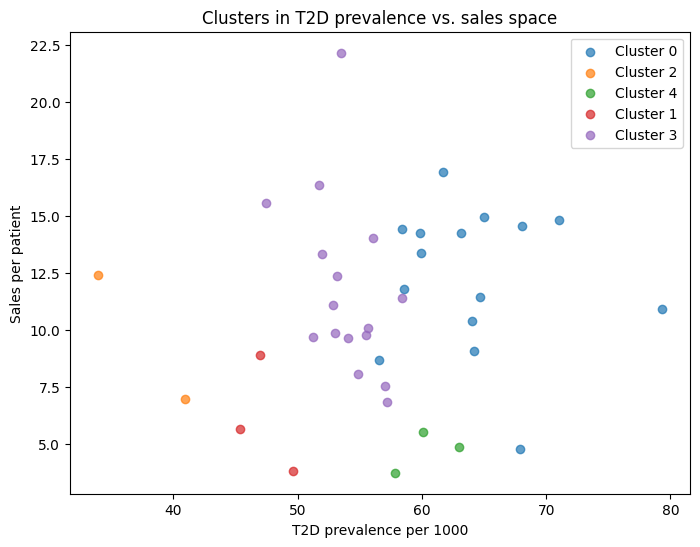

In [ ]:

plt.figure(figsize=(8,6))
for c in df_model['cluster'].unique():
    subset = df_model[df_model['cluster']==c]
    plt.scatter(subset['t2d_prevalence_per_1000'],
                subset['sales_per_patient'],
                label=f"Cluster {c}", alpha=0.7)

plt.xlabel("T2D prevalence per 1000")
plt.ylabel("Sales per patient")
plt.title("Clusters in T2D prevalence vs. sales space")
plt.legend()
plt.show()


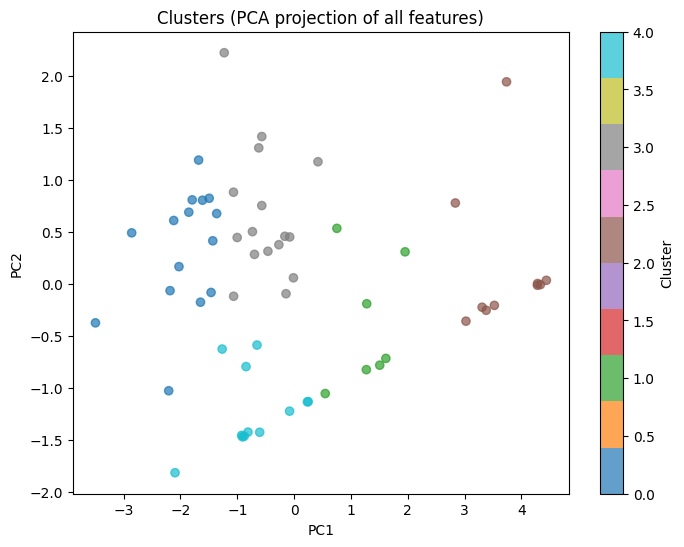

In [ ]:
from sklearn.decomposition import PCA

X_scaled = scaler.fit_transform(df_model[cluster_vars].fillna(0))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_model['cluster'], cmap='tab10', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters (PCA projection of all features)")
plt.colorbar(label="Cluster")
plt.show()


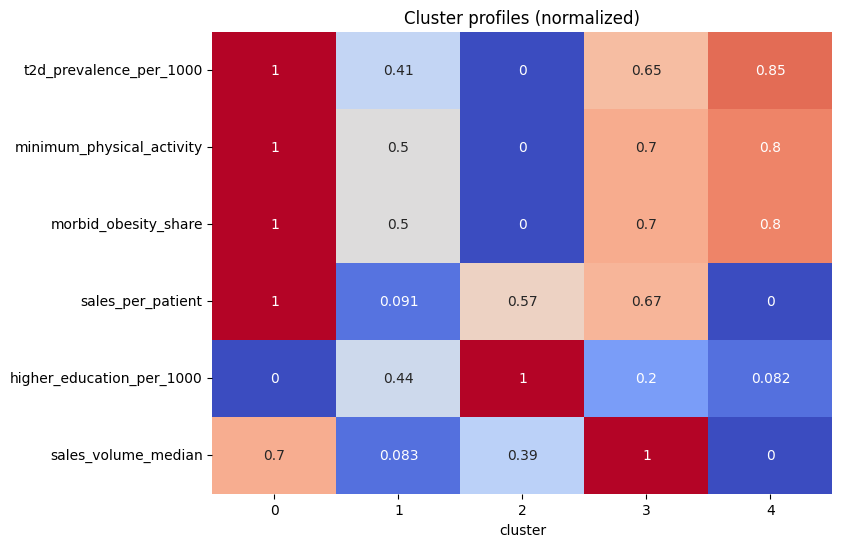

In [ ]:
import seaborn as sns

profile_norm = profile.copy()
# normalize by column so you see relative highs/lows
for col in profile_norm.columns:
    profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / (profile_norm[col].max() - profile_norm[col].min())

plt.figure(figsize=(8,6))
sns.heatmap(profile_norm.T, annot=True, cmap="coolwarm", cbar=False)
plt.title("Cluster profiles (normalized)")
plt.show()


In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np

# choose min_samples (rule of thumb)
min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# k-distance: take the kth neighbor distance for each point
k_dists = np.sort(distances[:, -1])
# Inspect k_dists curve visually (plot) to pick eps:
# plt.plot(k_dists); plt.title("k-distance plot"); plt.show()

eps_guess = np.percentile(k_dists, 90)  # starting point; adjust after inspecting plot
db = DBSCAN(eps=eps_guess, min_samples=min_samples).fit(X_scaled)
df_model['dbscan_label'] = db.labels_  # -1 are outliers

# quick DBSCAN profile (ignore outliers)
db_profile = (
    df_model[df_model['dbscan_label']!=-1]
      .groupby('dbscan_label')[cluster_vars + ['sales_volume']]
      .median().round(2)
)
print("DBSCAN clusters (labels):", np.unique(db.labels_))
print("Outliers (#):", (db.labels_==-1).sum())
print(db_profile)


NameError: name 'X_scaled' is not defined

DBSCAN grouped all municipalities into a single cluster and found no outliers. This indicates that the data is relatively homogeneous in density and that K-Means is a more suitable clustering method for this dataset

## Classisfication 

In [ ]:
# ---------------------------
# 1. Features and labels
# ---------------------------
X = df_model[[
    't2d_prevalence_per_1000',
    'minimum_physical_activity',
    'morbid_obesity_share',
    'sales_per_patient',
    'higher_education_per_1000'
]].copy()

y = df_model['cluster']   # target = cluster labels from KMeans

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ---------------------------
# 2. Train classifier
# ---------------------------
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

# ---------------------------
# 3. Evaluate performance
# ---------------------------
y_pred = clf.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Cluster Classification")
plt.show()

# ---------------------------
# 4. Feature importance
# ---------------------------
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== Feature Importances ===")
print(importances)

# Plot feature importance
importances.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance for Predicting Clusters")
plt.xlabel("Importance")
plt.show()


NameError: name 'df_model' is not defined